In [8]:

# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [9]:

# ── Constants ──────────────────────────────────────────────────────────────────
ROOT = "../../"

# Input paths
PARCEL_SHP      = ROOT + "data/geo/Parcels_7711352183771741448/Parcel_Boundaries.shp"
BUSINESS_XLSX   = ROOT + "data/business/Oakland_DataAxleV2.xlsx"

# Corridor shapefiles
OAK_BIDS_SHP        = ROOT + "data/corridors/OAK_BIDs/OAK_BIDs.shp"
POLICY_POLYGONS_SHP = ROOT + "data/corridors/Policy_Polygons/Policy_Polygons.shp"

# Output paths
OUT_DIR         = ROOT + "data/corridors/parcels/"
OUT_USE_CODE    = OUT_DIR + "parcels_use_code_filtered.gpkg"
OUT_BIZ_CONTAIN = OUT_DIR + "parcels_with_business.gpkg"
OUT_UNION       = OUT_DIR + "parcels_union.gpkg"

# Use code prefixes to keep (3xxx, 8xxx, 9xxx)
USE_CODE_PREFIXES = ("3", "8", "9")

# Coordinate reference systems
PARCEL_CRS   = "EPSG:3857"   # Web Mercator (native CRS of the parcel shapefile)
BUSINESS_CRS = "EPSG:4326"   # WGS 84 (lat/lon of the business data)
CORRIDOR_CRS = "EPSG:4269"   # NAD 83 (native CRS of the corridor shapefiles)



# Section 1 — Identify Preliminary Corridor Parcels

This section filters the Alameda County parcel dataset to produce three targeted parcel layers,
all saved as GeoPackage files under `data/corridors/parcels/`:

| Output file | Description |
|---|---|
| `parcels_use_code_filtered.gpkg` | Parcels whose `UseCode` starts with 3, 8, or 9 (commercial / industrial / special use) |
| `parcels_with_business.gpkg` | Parcels that contain at least one DataAxle business centroid |
| `parcels_union.gpkg` | Union of the two filtered sets (deduplicated) |



## 1.1 Load Parcel Data

Read the full Alameda County parcel shapefile into a GeoDataFrame.  
The native CRS is **EPSG:3857** (Web Mercator).


In [3]:

# Load full parcel shapefile (~1 GB on disk; reads into memory as a GeoDataFrame)
parcels = gpd.read_file(PARCEL_SHP)

print(f"Total parcels loaded : {len(parcels):,}")
print(f"CRS                  : {parcels.crs}")
print(f"UseCode sample values: {parcels['UseCode'].dropna().unique()[:10]}")


Total parcels loaded : 489,576
CRS                  : EPSG:3857
UseCode sample values: ['1100' '0800' '3600' '0500' '0300' '8300' '4100' '4102' '2500' '3000']



## 1.2 Filter Parcels by Use Code (3xxx / 8xxx / 9xxx)

Retain only parcels whose 4-digit `UseCode` begins with **3** (commercial),
**8** (institutional / public), or **9** (miscellaneous / special).  
The result is saved to `parcels_use_code_filtered.gpkg`.


In [4]:

# Cast UseCode to string and normalise to 4 characters (zero-pad if needed),
# then keep rows whose first character matches one of the target prefixes.
parcels["UseCode_str"] = (
    parcels["UseCode"]
    .astype(str)
    .str.strip()
    .str.zfill(4)
)

mask_use_code = parcels["UseCode_str"].str[0].isin(list(USE_CODE_PREFIXES))
parcels_use_code = parcels[mask_use_code].copy()

print(f"Parcels matching 3xxx/8xxx/9xxx use codes : {len(parcels_use_code):,}")
print(parcels_use_code["UseCode_str"].value_counts().head(15))

# Save to GeoPackage
os.makedirs(OUT_DIR, exist_ok=True)
parcels_use_code.to_file(OUT_USE_CODE, driver="GPKG")
print(f"\nSaved → {OUT_USE_CODE}")


Parcels matching 3xxx/8xxx/9xxx use codes : 15,038
UseCode_str
3100    2361
3200    1961
9400    1475
3000     948
3900     856
8100     813
9300     676
8300     668
3600     642
3300     606
9401     523
9901     517
3700     456
8500     395
8200     222
Name: count, dtype: int64

Saved → ../../data/corridors/parcels/parcels_use_code_filtered.gpkg



## 1.3 Load Business Data and Build GeoDataFrame

Read the DataAxle business registry from the Excel file.  
`Latitude` / `Longitude` are in **WGS 84 (EPSG:4326)**, so we construct point
geometries and then reproject to match the parcel CRS (**EPSG:3857**) before
performing the spatial join.


In [5]:

# Load business registry (only need the coordinate columns for spatial work)
businesses_df = pd.read_excel(BUSINESS_XLSX)

# Drop rows that have no usable coordinates
businesses_df = businesses_df.dropna(subset=["Latitude", "Longitude"])

print(f"Businesses with valid coordinates : {len(businesses_df):,}")

# Build GeoDataFrame — points from lat/lon (WGS 84)
businesses_gdf = gpd.GeoDataFrame(
    businesses_df,
    geometry=gpd.points_from_xy(businesses_df["Longitude"], businesses_df["Latitude"]),
    crs=BUSINESS_CRS,
)

# Reproject to the same CRS as the parcel layer (EPSG:3857)
businesses_gdf = businesses_gdf.to_crs(PARCEL_CRS)

print(f"Business CRS after reprojection   : {businesses_gdf.crs}")


Businesses with valid coordinates : 29,545
Business CRS after reprojection   : EPSG:3857



## 1.4 Filter Parcels That Contain a Business Centroid

Use a spatial join (`predicate="contains"`) to find every parcel polygon that
contains at least one business point.  We then deduplicate by parcel index so
each parcel appears only once regardless of how many businesses it contains.  
The result is saved to `parcels_with_business.gpkg`.


In [6]:

# Spatial join: keep only parcel rows that contain ≥1 business point.
# how="inner" returns one row per (parcel, business) match — we deduplicate after.
joined = gpd.sjoin(
    parcels,                   # left  — polygon layer
    businesses_gdf[["geometry"]],  # right — point layer (geometry only to keep output slim)
    how="inner",
    predicate="contains",
)

# Deduplicate: one row per parcel (a parcel may match many businesses)
parcels_with_biz = parcels.loc[joined.index.unique()].copy()

print(f"Parcels containing ≥1 business centroid : {len(parcels_with_biz):,}")

# Save to GeoPackage
parcels_with_biz.to_file(OUT_BIZ_CONTAIN, driver="GPKG")
print(f"Saved → {OUT_BIZ_CONTAIN}")


Parcels containing ≥1 business centroid : 16,041
Saved → ../../data/corridors/parcels/parcels_with_business.gpkg



## 1.5 Build the Union Layer

Concatenate the two filtered parcel sets and drop duplicate rows (by original
DataFrame index) so that a parcel matching both criteria appears only once.  
The result is saved to `parcels_union.gpkg`.


In [7]:

# Combine the two filtered layers and deduplicate by original row index
parcels_union = (
    pd.concat([parcels_use_code, parcels_with_biz])
    .pipe(gpd.GeoDataFrame, crs=PARCEL_CRS)
    # Reset index to expose it as a column, drop duplicate original indices
    .reset_index(drop=False)
    .drop_duplicates(subset="index")
    .set_index("index")
)

print(f"Parcels in use-code filter   : {len(parcels_use_code):,}")
print(f"Parcels with business        : {len(parcels_with_biz):,}")
print(f"Parcels in union (no dups)   : {len(parcels_union):,}")

# Save to GeoPackage
parcels_union.to_file(OUT_UNION, driver="GPKG")
print(f"\nSaved → {OUT_UNION}")


Parcels in use-code filter   : 15,038
Parcels with business        : 16,041
Parcels in union (no dups)   : 28,236

Saved → ../../data/corridors/parcels/parcels_union.gpkg



# Section 2 — Corridor Coverage Analysis

The existing corridor definitions come from two sources:

| Layer | Description | Features |
|---|---|---|
| **OAK_BIDs** | Oakland Business Improvement Districts | 11 named BIDs |
| **Policy_Polygons** | Researcher-defined policy study areas | 9 named areas |

For each layer — individually and combined — we measure how well the corridor boundaries
capture the **three parcel filters** produced in Section 1:

* **Use-code parcels** — 3xxx / 8xxx / 9xxx
* **Business-containing parcels** — has ≥ 1 DataAxle business inside
* **Union parcels** — either of the above

Coverage is expressed as both **raw counts** and **% of each filtered set**.



## 2.1 Load and Reproject Corridor Layers

Both corridor shapefiles are in **EPSG:4269** (NAD 83).  We reproject them to
**EPSG:3857** to match the parcel layer before any spatial operations.  We also
build a single combined layer that is the union of both corridor geometries.


In [11]:

# Load corridor layers and reproject to match parcels (EPSG:3857)
oak_bids = gpd.read_file(OAK_BIDS_SHP).to_crs(PARCEL_CRS)
policy   = gpd.read_file(POLICY_POLYGONS_SHP).to_crs(PARCEL_CRS)

# Combined layer: dissolve both into a single multipolygon union
from shapely.ops import unary_union
combined_geom = unary_union(
    oak_bids.geometry.tolist() + policy.geometry.tolist()
)
combined = gpd.GeoDataFrame(geometry=[combined_geom], crs=PARCEL_CRS)

print(f"OAK_BIDs   : {len(oak_bids)} corridors  | CRS: {oak_bids.crs}")
print(f"Policy     : {len(policy)} areas       | CRS: {policy.crs}")
print(f"OAK BID names   : {oak_bids['BID'].tolist()}")
print(f"Policy names    : {policy['PP_Name'].tolist()}")


OAK_BIDs   : 11 corridors  | CRS: EPSG:3857
Policy     : 9 areas       | CRS: EPSG:3857
OAK BID names   : ['Downtown', 'Chinatown', 'Lake Merritt', 'Koreatown/Northgate', 'Montclair', 'Rockridge', 'Temescal/Telegraph', 'Fruitvale', 'Lakeshore', 'Jack London', 'Laurel']
Policy names    : ['Seventh Thrives', 'West Oakland S', 'Little Saigon', 'Hegenberger_BID', 'Beat19x', 'Fruitvale_BID', 'Telegraph Triangle', 'Old_Oakland', 'Dimond']



## 2.2 Coverage Helper

A reusable function counts, for a given parcel set, how many parcel centroids
fall **within** a corridor layer.  Using centroids (rather than full polygon
intersection) avoids partial-overlap ambiguity and is fast even on large sets.


In [12]:

def count_covered(parcel_gdf: gpd.GeoDataFrame, corridor_gdf: gpd.GeoDataFrame) -> int:
    """Return the number of parcels whose centroid lies within any corridor polygon."""
    centroids = parcel_gdf.copy()
    centroids["geometry"] = parcel_gdf.geometry.centroid
    joined = gpd.sjoin(centroids[["geometry"]], corridor_gdf[["geometry"]], how="inner", predicate="within")
    return joined.index.nunique()


def coverage_stats(parcel_sets: dict, corridor_layers: dict) -> pd.DataFrame:
    """
    Build a tidy coverage table.

    Parameters
    ----------
    parcel_sets    : {label: GeoDataFrame}  — the filtered parcel layers
    corridor_layers: {label: GeoDataFrame}  — the corridor layers to test

    Returns
    -------
    DataFrame with columns: corridor, parcel_set, total, covered, pct_covered
    """
    rows = []
    for c_name, corridors in corridor_layers.items():
        for p_name, parcels in parcel_sets.items():
            total   = len(parcels)
            covered = count_covered(parcels, corridors)
            rows.append({
                "corridor"   : c_name,
                "parcel_set" : p_name,
                "total"      : total,
                "covered"    : covered,
                "pct_covered": round(covered / total * 100, 1) if total else 0.0,
            })
    return pd.DataFrame(rows)



## 2.3 Overall Coverage Summary Table

Run the coverage helper across all three parcel sets × three corridor configurations.


In [13]:

parcel_sets = {
    "Use-code (3/8/9xxx)" : parcels_use_code,
    "Has business"        : parcels_with_biz,
    "Union"               : parcels_union,
}

corridor_layers = {
    "OAK BIDs"   : oak_bids,
    "Policy"     : policy,
    "Combined"   : combined,
}

coverage_df = coverage_stats(parcel_sets, corridor_layers)

# Pivot for readability: corridors as rows, parcel sets as columns (% covered)
pivot_pct = coverage_df.pivot(index="corridor", columns="parcel_set", values="pct_covered")
pivot_n   = coverage_df.pivot(index="corridor", columns="parcel_set", values="covered")

print("=== Parcels covered (count) ===")
print(pivot_n.to_string())
print()
print("=== Parcels covered (%) ===")
print(pivot_pct.to_string())


=== Parcels covered (count) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            6079   6941                 2470
OAK BIDs            4355   4911                 1845
Policy              2154   2600                  967

=== Parcels covered (%) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            37.9   24.6                 16.4
OAK BIDs            27.1   17.4                 12.3
Policy              13.4    9.2                  6.4



## 2.4 Coverage Bar Chart — % of Each Parcel Set Captured

Grouped bar chart showing what share of each filtered parcel set is captured
by OAK BIDs, Policy Polygons, and their combination.


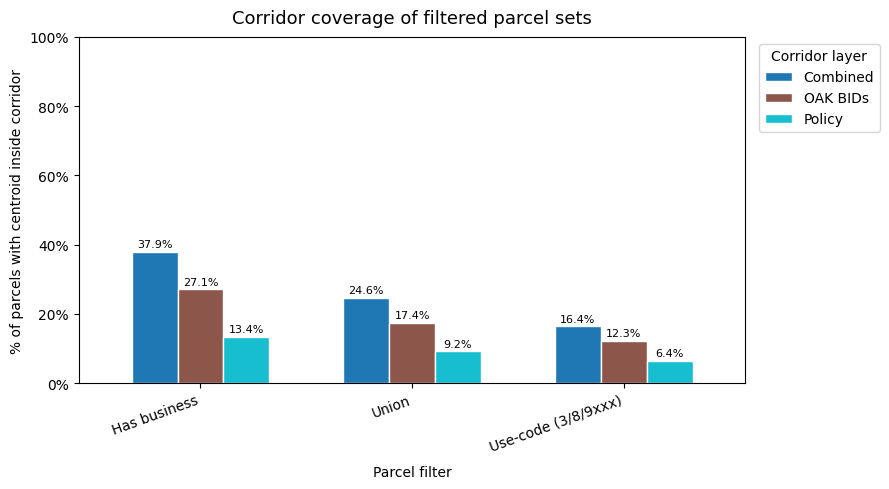

In [14]:

fig, ax = plt.subplots(figsize=(9, 5))

pivot_pct.T.plot(
    kind="bar",
    ax=ax,
    width=0.65,
    colormap="tab10",
    edgecolor="white",
)

ax.set_title("Corridor coverage of filtered parcel sets", fontsize=13, pad=10)
ax.set_xlabel("Parcel filter", labelpad=8)
ax.set_ylabel("% of parcels with centroid inside corridor")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Corridor layer", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)

# Annotate each bar with its value
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=8, padding=2)

plt.tight_layout()
plt.show()



## 2.8 Spatial Map — Corridors vs. Union Parcels

A quick map to visualise which parts of the East Bay the corridor layers cover
relative to the full union parcel set.  Parcel centroids are plotted as grey
dots; corridor outlines are overlaid on top.


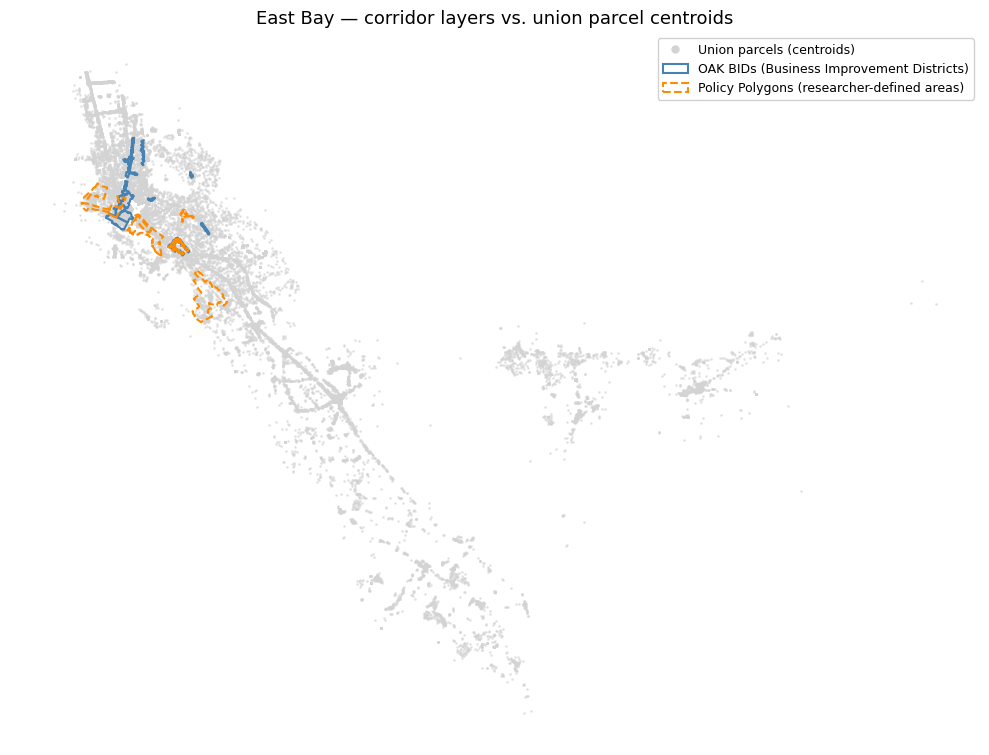

In [20]:

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

fig, ax = plt.subplots(figsize=(10, 10))

# Plot union parcel centroids as light grey dots
union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.5)

# OAK BIDs — solid blue outlines
oak_bids.plot(ax=ax, facecolor="none", edgecolor="steelblue", linewidth=1.5)

# Policy Polygons — dashed orange outlines
policy.plot(ax=ax, facecolor="none", edgecolor="darkorange", linewidth=1.5, linestyle="--")

# Build explicit legend handles so all three items appear
legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="none", edgecolor="steelblue", linewidth=1.5,
                   label="OAK BIDs (Business Improvement Districts)"),
    mpatches.Patch(facecolor="none", edgecolor="darkorange", linewidth=1.5,
                   linestyle="--", label="Policy Polygons (researcher-defined areas)"),
]

ax.set_title("East Bay — corridor layers vs. union parcel centroids", fontsize=13)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()
